In [1]:
import os
import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

import joblib

In [3]:
DATA_DIR = "../data/processed"

nc_files = sorted(
    glob.glob(os.path.join(DATA_DIR, "*.nc"))
)

print("Files found:")

for file in nc_files:
    print(file)

print("\nNumber of files:", len(nc_files))

if len(nc_files) != 6:
    print("WARNING: Expected 6 NetCDF files.")

datasets = []

for file in nc_files:
    ds_temp = xr.open_dataset(file)
    datasets.append(ds_temp)

print("All files loaded successfully.")    

Files found:
../data/processed\glorys_2021_01_025deg.nc
../data/processed\glorys_2021_01_06_025deg_clean.nc
../data/processed\glorys_2021_02_025deg.nc
../data/processed\glorys_2021_03_025deg.nc
../data/processed\glorys_2021_04_025deg.nc
../data/processed\glorys_2021_05_025deg.nc
../data/processed\glorys_2021_06_025deg.nc

Number of files: 7
All files loaded successfully.


In [4]:
ds = xr.concat(
    datasets,
    dim="time"
)

print("Combined dataset:")
print(ds)

Combined dataset:
<xarray.Dataset> Size: 1GB
Dimensions:    (time: 362, depth: 35, latitude: 101, longitude: 241)
Coordinates:
  * time       (time) datetime64[ns] 3kB 2021-01-01 2021-01-02 ... 2021-06-30
  * depth      (depth) float32 140B 0.494 1.541 2.646 ... 643.6 763.3 902.3
  * latitude   (latitude) float32 404B 5.0 5.25 5.5 5.75 ... 29.5 29.75 30.0
  * longitude  (longitude) float32 964B 45.0 45.25 45.5 ... 104.5 104.8 105.0
Data variables:
    thetao     (time, depth, latitude, longitude) float32 1GB nan nan ... nan


In [5]:
print("Dimensions:")
print(ds.dims)

print("\nCoordinates:")
print(ds.coords)

print("\nVariables:")
print(ds.data_vars)

Dimensions:
FrozenMappingWarningOnValuesAccess({'time': 362, 'depth': 35, 'latitude': 101, 'longitude': 241})

Coordinates:
Coordinates:
  * time       (time) datetime64[ns] 3kB 2021-01-01 2021-01-02 ... 2021-06-30
  * depth      (depth) float32 140B 0.494 1.541 2.646 ... 643.6 763.3 902.3
  * latitude   (latitude) float32 404B 5.0 5.25 5.5 5.75 ... 29.5 29.75 30.0
  * longitude  (longitude) float32 964B 45.0 45.25 45.5 ... 104.5 104.8 105.0

Variables:
Data variables:
    thetao   (time, depth, latitude, longitude) float32 1GB nan nan ... nan nan


In [7]:
print(ds["thetao"])
missing_count = ds["thetao"].isnull().sum().item()

print("Missing thetao values:", missing_count)
print("Mean:", ds["thetao"].mean().item())
print("Minimum:", ds["thetao"].min().item())
print("Maximum:", ds["thetao"].max().item())

<xarray.DataArray 'thetao' (time: 362, depth: 35, latitude: 101, longitude: 241)> Size: 1GB
array([[[[      nan,       nan,       nan, ..., 27.537066, 27.35249 ,
          27.039736],
         [      nan,       nan,       nan, ..., 27.460157, 27.26313 ,
          26.964293],
         [      nan,       nan,       nan, ..., 27.394238, 27.287302,
          27.021423],
         ...,
         [      nan,       nan,       nan, ...,       nan,       nan,
                nan],
         [      nan,       nan,       nan, ...,       nan,       nan,
                nan],
         [      nan,       nan,       nan, ...,       nan,       nan,
                nan]],

        [[      nan,       nan,       nan, ..., 27.537066, 27.35249 ,
          27.039003],
         [      nan,       nan,       nan, ..., 27.460157, 27.26313 ,
          26.964293],
         [      nan,       nan,       nan, ..., 27.394238, 27.287302,
          27.021423],
...
         [      nan,       nan,       nan, ...,       nan,  

In [13]:
# Convert thetao to DataFrame
df = ds["thetao"].to_dataframe(
    name="thetao"
).reset_index()

print("Original shape:", df.shape)

# Keep only observations where thetao is available
df = df[df["thetao"].notna()].copy()

print("Shape after selecting valid thetao:")
print(df.shape)

print("\nRemaining missing thetao:")
print(df["thetao"].isna().sum())

Original shape: (308400470, 5)
Shape after selecting valid thetao:
(136969940, 5)

Remaining missing thetao:
0


In [14]:
df["year"] = df["time"].dt.year

df["month"] = df["time"].dt.month

df["day_of_year"] = df["time"].dt.dayofyear

df["month_sin"] = np.sin(
    2 * np.pi * df["month"] / 12
)

df["month_cos"] = np.cos(
    2 * np.pi * df["month"] / 12
)

In [16]:
feature_columns = [
    "latitude",
    "longitude",
    "depth",
    "year",
    "day_of_year",
    "month_sin",
    "month_cos"
]

X = df[feature_columns]

y = df["thetao"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(feature_columns)
print("\nMissing values in X:")
print(X.isna().sum())

print("\nMissing values in y:")
print(y.isna().sum())

X shape: (136969940, 7)
y shape: (136969940,)

Features:
['latitude', 'longitude', 'depth', 'year', 'day_of_year', 'month_sin', 'month_cos']

Missing values in X:
latitude       0
longitude      0
depth          0
year           0
day_of_year    0
month_sin      0
month_cos      0
dtype: int64

Missing values in y:
0


In [24]:

df_model = df.sample(
    n=2_000_000,
    random_state=42
).sort_values("time")

In [25]:
# Make sure time is datetime
df_model["time"] = pd.to_datetime(df_model["time"])

# Sort by time
df_model = df_model.sort_values("time").reset_index(drop=True)

# Calculate split indices
n = len(df_model)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

# Split chronologically
train_df = df_model.iloc[:train_end]
val_df = df_model.iloc[train_end:val_end]
test_df = df_model.iloc[val_end:]

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain period:")
print(train_df["time"].min(), "to", train_df["time"].max())

print("\nValidation period:")
print(val_df["time"].min(), "to", val_df["time"].max())

print("\nTest period:")
print(test_df["time"].min(), "to", test_df["time"].max())


Train: (1400000, 10)
Validation: (300000, 10)
Test: (300000, 10)

Train period:
2021-01-01 00:00:00 to 2021-05-07 00:00:00

Validation period:
2021-05-07 00:00:00 to 2021-06-03 00:00:00

Test period:
2021-06-03 00:00:00 to 2021-06-30 00:00:00


In [26]:
def create_features(data):
    data = data.copy()

    data["year"] = data["time"].dt.year
    data["day_of_year"] = data["time"].dt.dayofyear
    data["month"] = data["time"].dt.month

    # Cyclic representation of seasonality
    data["month_sin"] = np.sin(2 * np.pi * data["month"] / 12)
    data["month_cos"] = np.cos(2 * np.pi * data["month"] / 12)

    return data


train_df = create_features(train_df)
val_df = create_features(val_df)
test_df = create_features(test_df)

print(train_df.head())

        time      depth  latitude  longitude     thetao  year  month  \
0 2021-01-01  77.853851      8.25      86.00  27.430861  2021      1   
1 2021-01-01  40.344051      5.25      51.50  26.166662  2021      1   
2 2021-01-01  65.807266      9.25      50.75  25.338886  2021      1   
3 2021-01-01   6.440614      9.75      97.75  28.539049  2021      1   
4 2021-01-01   5.078224      8.25      73.50  28.825434  2021      1   

   day_of_year  month_sin  month_cos  
0            1        0.5   0.866025  
1            1        0.5   0.866025  
2            1        0.5   0.866025  
3            1        0.5   0.866025  
4            1        0.5   0.866025  


In [27]:
features = [
    "latitude",
    "longitude",
    "depth",
    "year",
    "day_of_year",
    "month_sin",
    "month_cos"
]

target = "thetao"

X_train = train_df[features].values
y_train = train_df[target].values

X_val = val_df[features].values
y_val = val_df[target].values

X_test = test_df[features].values
y_test = test_df[target].values

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (1400000, 7)
y_train: (1400000,)
X_val: (300000, 7)
y_val: (300000,)
X_test: (300000, 7)
y_test: (300000,)


In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


In [29]:
os.makedirs("../models", exist_ok=True)

joblib.dump(
    scaler,
    "../models/baseline_scaler.pkl"
)

print("Scaler saved.")

Scaler saved.


In [30]:
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1, activation="linear")
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

C:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625 (10.25 KB)

 Trainable params: 2,625 (10.25 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=1024,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 43.8523 - mae: 3.3043 - val_loss: 7.0216 - val_mae: 1.8882
Epoch 2/100
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1.1987 - mae: 0.7994 - val_loss: 3.9188 - val_mae: 1.4023
Epoch 3/100
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.7139 - mae: 0.6037 - val_loss: 2.7504 - val_mae: 1.1692
Epoch 4/100
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.6379 - mae: 0.5632 - val_loss: 2.4097 - val_mae: 1.0819
Epoch 5/100
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.5895 - mae: 0.5373 - val_loss: 2.8206 - val_mae: 1.1285
Epoch 6/100
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.5458 - mae: 0.5136 - val_loss: 2.7326 - val_mae: 1.0816
Epoch 7/100
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.5162 - mae: 0.4965 - val_loss: 2.9368 - val_mae: 1.1000
Epoch 8/100
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.4973 - mae: 0.4864 - val_loss: 3.3978 - val_mae: 1.1436
Epoch 9/100
1368/1368 ━━━━━━━━━

In [32]:
y_pred = model.predict(
    X_test_scaled,
    batch_size=1024
).flatten()

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Baseline ANN Results")
print("--------------------")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Baseline ANN Results
--------------------
MSE : 14.0873384475708
RMSE: 3.7533103319031325
MAE : 3.260779619216919
R²  : 0.7486555576324463


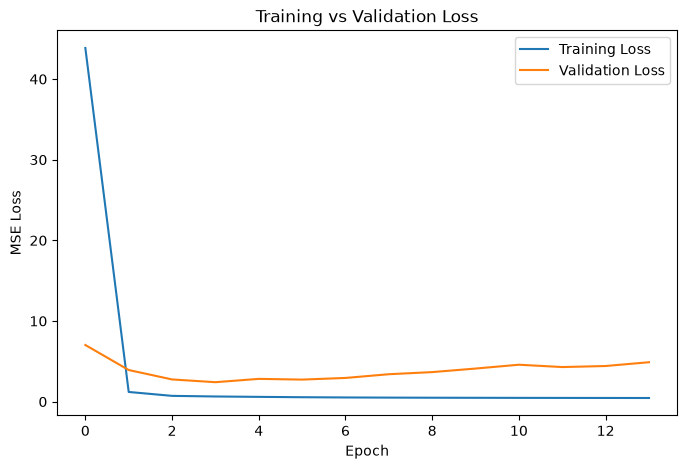

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

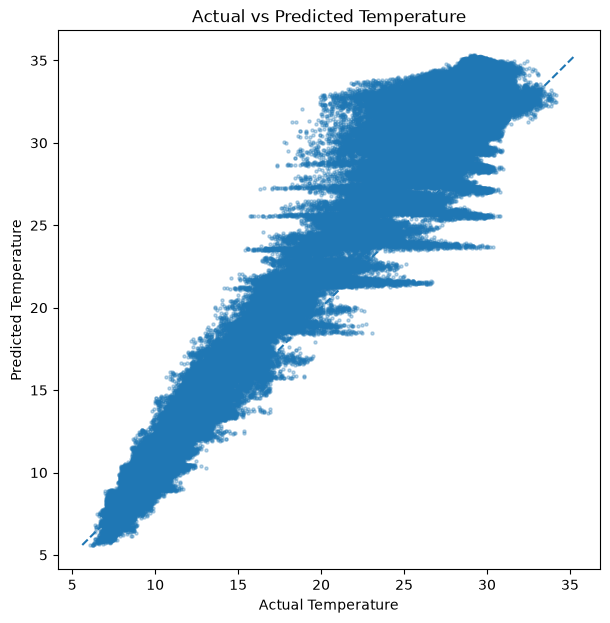

In [34]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred,
    s=5,
    alpha=0.3
)

# Perfect prediction line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Temperature")

plt.show()

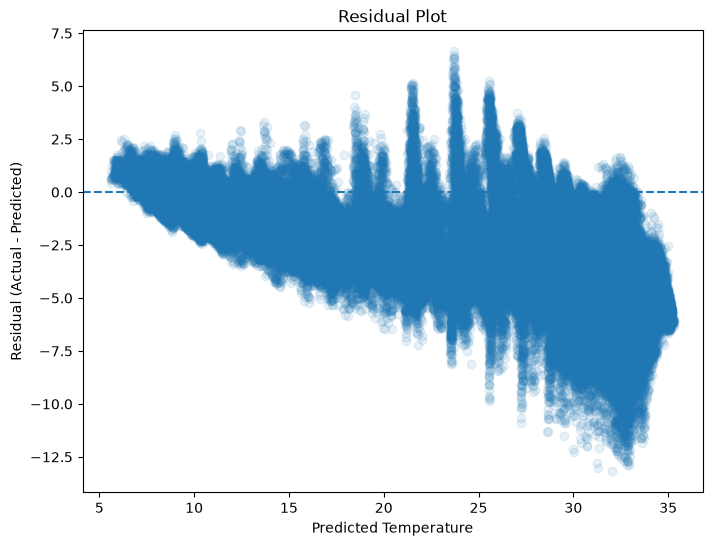

In [ ]:
errors = y_test - y_pred
plt.figure(figsize=(8, 6))

plt.scatter(y_pred, errors, alpha=0.1)

plt.axhline(0, linestyle='--')

plt.xlabel("Predicted Temperature")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")

plt.show()

#  the graph below shows that for higher temperature
#  the model is overpredicting in negative values
#  ist is due to taking input features only time,depth,lat,long only